In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(" STEP 1: LOAD AND UNDERSTAND THE DATA")
print("="*60)
column_names = [
    'age',                    # Age in years (numeric)
    'workclass',              # Type of employer (Private, Self-emp, Government, etc.)
    'fnlwgt',                 # Census weight (how many people this row represents)
    'education',              # Highest education level (Bachelors, HS-grad, etc.)
    'education_num',          # Education level as number (higher = more education)
    'marital_status',         # Married, Divorced, Never-married, etc.
    'occupation',             # Job type (Tech-support, Craft-repair, etc.)
    'relationship',           # Role in family (Husband, Wife, Own-child, etc.)
    'race',                   # Race category
    'sex',                    # Male/Female
    'capital_gain',           # Profit from investments (numeric)
    'capital_loss',           # Loss from investments (numeric)
    'hours_per_week',         # Hours worked per week (numeric)
    'native_country',         # Country of origin
    'income'                  # TARGET: >50K or <=50K (what we want to predict)
]


df = pd.read_csv('adult.data.csv', 
                 names=column_names, 
                 na_values=' ?',        # '?' means missing data
                 skipinitialspace=True) # Remove extra spaces

print(f" Loaded {len(df):,} people's census records")
print(f" Each person has {len(df.columns)} pieces of information")

 STEP 1: LOAD AND UNDERSTAND THE DATA
 Loaded 32,561 people's census records
 Each person has 15 pieces of information


Understanding Our Target
Income distribution
  : 24,720 people (75.9%)
  :  7,841 people (24.1%)


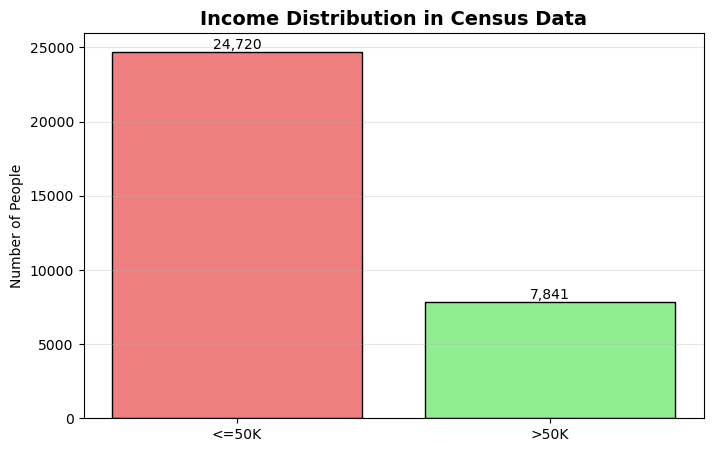


 KEY INSIGHT: This is an IMBALANCED dataset
   Only 24.1% of people earn >50K
   Our model must learn from this imbalance!


In [2]:
print("Understanding Our Target")
print("=" * 60)

target_counts = df['income'].value_counts()#grouping into high and low income 
target_percentage = df['income'].value_counts(normalize =True) * 100#findig the percentage of thr groupings 

print("Income distribution")
print(f"  : {target_counts['<=50K']:6,d} people ({target_percentage['<=50K']:.1f}%)")
print(f"  : {target_counts['>50K']:6,d} people ({target_percentage['>50K']:.1f}%)")

plt.figure(figsize=(8,5))
bars = plt.bar(['<=50K','>50K'],[target_counts['<=50K'], target_counts['>50K']],
color=['lightcoral', 'lightgreen'],
edgecolor='black')

for bar in bars :
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.,height,
    f'{int(height):,}',ha='center', va='bottom')

plt.title('Income Distribution in Census Data', fontsize=14, fontweight='bold')
plt.ylabel('Number of People')
plt.grid(True,alpha = 0.3,axis = 'y')
plt.show()

print("\n KEY INSIGHT: This is an IMBALANCED dataset")
print("   Only {:.1f}% of people earn >50K".format(target_percentage['>50K']))
print("   Our model must learn from this imbalance!")






 STEP 3: NUMERICAL FEATURES (Numbers we can do math with)
Categorical features:
 * workclass
 * education
 * marital_status
 * occupation
 * relationship
 * race
 * sex
 * native_country
Unique values per category
workclass: 9 unique values
education: 16 unique values
marital_status: 7 unique values
occupation: 15 unique values
relationship: 6 unique values
race: 5 unique values
sex: 2 unique values
native_country: 42 unique values


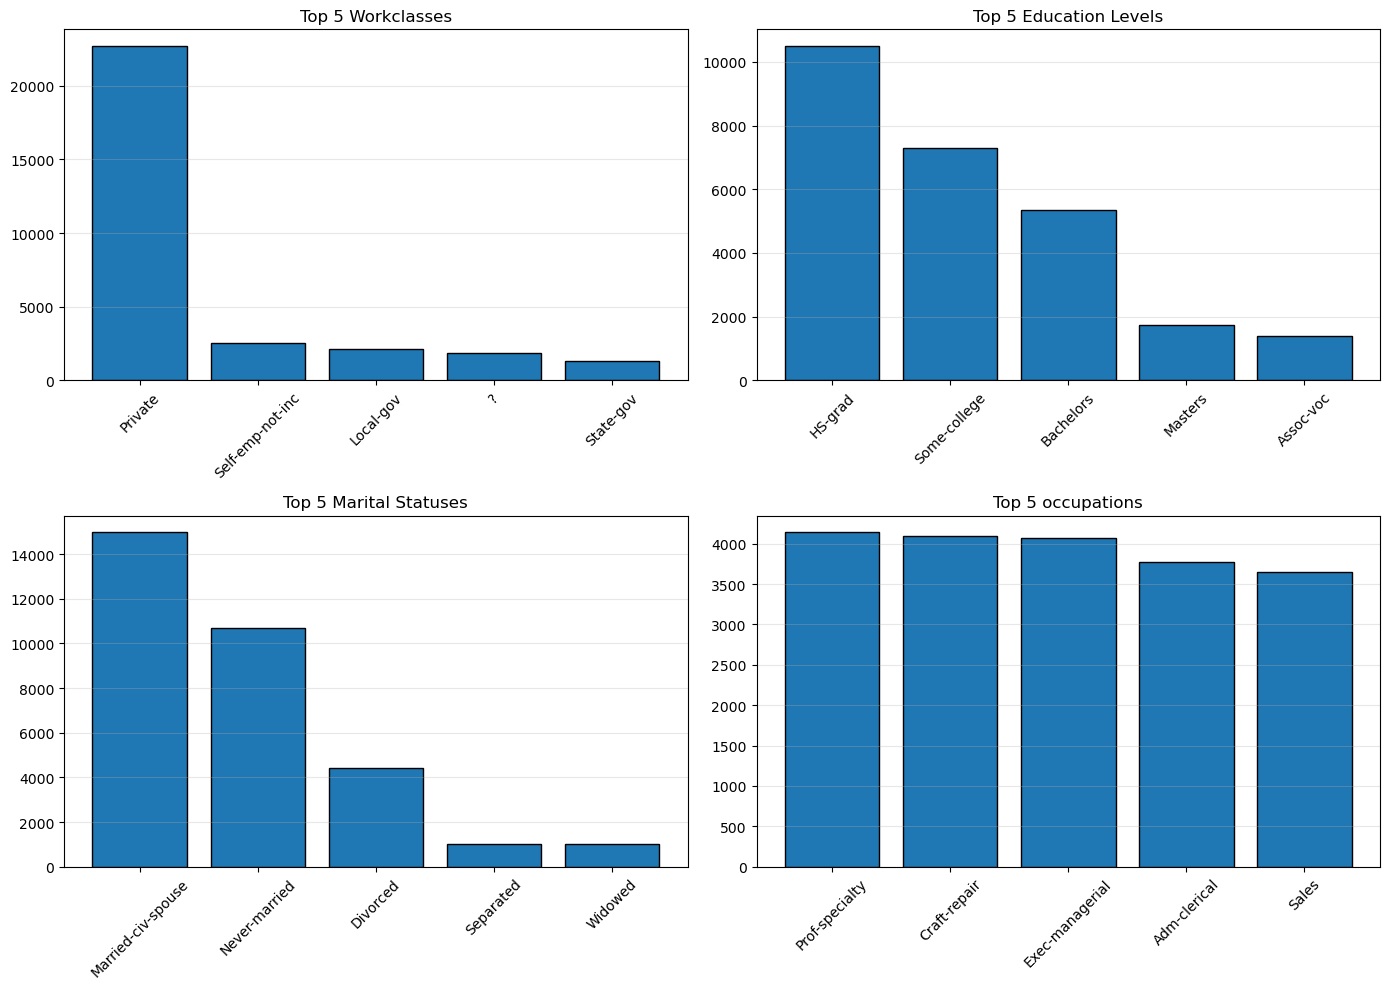

In [3]:
#understanding wah we are predicting
print(" STEP 3: NUMERICAL FEATURES (Numbers we can do math with)")
print("=" * 60)


categorical_cols = ['workclass' ,'education', 'marital_status','occupation','relationship','race' , 'sex' , 'native_country']

print("Categorical features:")
for col in categorical_cols:
    print(f" * {col}")

print("Unique values per category")
for col in categorical_cols:
    n_unique = df[col].nunique() #nunique counts how many distinct categories exist in each column
    print(f"{col}: {n_unique} unique values")
    

fig,axes = plt.subplots(2,2, figsize = (14 ,10))

workclass  = df['workclass'].value_counts().head(5)#counts frequency of each category and picks top 5
axes[0,0].bar(workclass.index,workclass.values,edgecolor ='black')
axes[0, 0].set_title('Top 5 Workclasses')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

education = df['education'].value_counts().head(5)
axes[0,1].bar(education.index,education.values,edgecolor = 'black')
axes[0,1].set_title('Top 5 Education Levels')
axes[0,1].tick_params(axis='x',rotation=45)
axes[0,1].grid(True,alpha=0.3,axis= 'y')

marital_status = df['marital_status'].value_counts().head(5)
axes[1,0].bar(marital_status.index,marital_status.values, edgecolor='black')
axes[1,0].set_title('Top 5 Marital Statuses')
axes[1,0].tick_params(axis = 'x',rotation = 45)
axes[1,0].grid(True,alpha=0.3,axis = 'y')

occupation = df['occupation'].value_counts().head(5)
axes[1,1].bar(occupation.index,occupation.values, edgecolor ='black')
axes[1,1].set_title('Top 5 occupations')
axes[1,1].tick_params(axis = 'x' , rotation = 45)
axes[1,1].grid(True,alpha = 0.3, axis = 'y')

plt.tight_layout()
plt.show()

NUMERICAL FEATURES(Numbers we can do math with)
Statistical Summary:
           age     fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.0    32561.0        32561.0       32561.0       32561.0   
mean      38.6   189778.4           10.1        1077.6          87.3   
std       13.6   105550.0            2.6        7385.3         403.0   
min       17.0    12285.0            1.0           0.0           0.0   
25%       28.0   117827.0            9.0           0.0           0.0   
50%       37.0   178356.0           10.0           0.0           0.0   
75%       48.0   237051.0           12.0           0.0           0.0   
max       90.0  1484705.0           16.0       99999.0        4356.0   

       hours_per_week  
count         32561.0  
mean             40.4  
std              12.3  
min               1.0  
25%              40.0  
50%              40.0  
75%              45.0  
max              99.0  


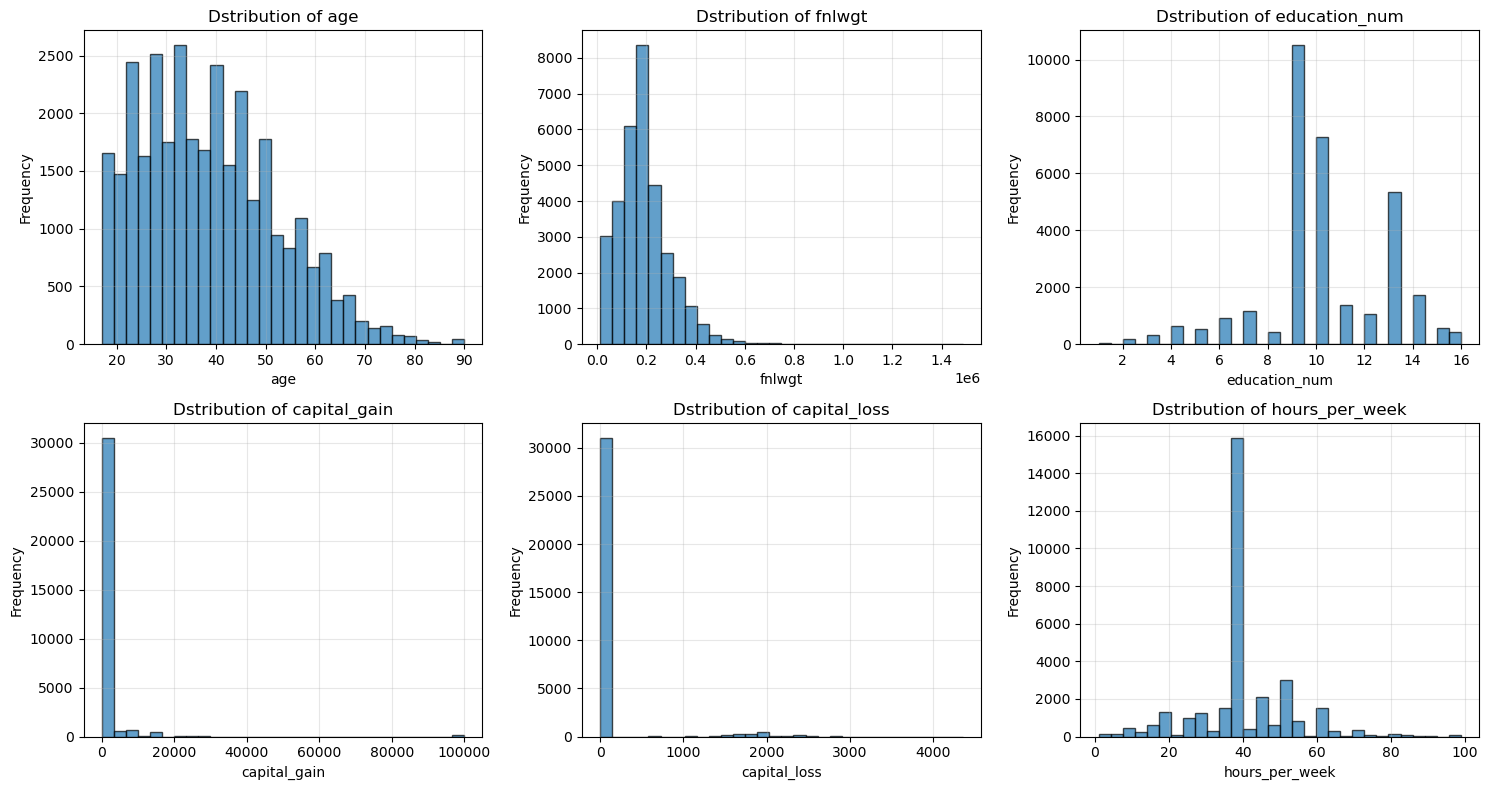


 KEY INSIGHTS:
  • Age ranges from 17 to 90 - working age population
  • Most people work 40 hours/week (standard full-time)
  • Capital gain/loss is 0 for most people (skewed data)


In [4]:
#Understanding numerical features
print("NUMERICAL FEATURES(Numbers we can do math with)")
print("="*60)

numerical_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 
                  'capital_loss', 'hours_per_week']

print("Statistical Summary:")
print(df[numerical_cols].describe().round(1))

fig,axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.flatten()

for i,col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(),bins = 30,edgecolor='black',alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Dstribution of {col}')
    axes[i].grid(True,alpha=0.3)


plt.tight_layout()
plt.show()

print("\n KEY INSIGHTS:")
print("  • Age ranges from 17 to 90 - working age population")
print("  • Most people work 40 hours/week (standard full-time)")
print("  • Capital gain/loss is 0 for most people (skewed data)")



In [5]:
print("Cleaning Data")
print("=" * 60)

missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) > 0:
    print("Missing values found")
    for col , count in missing_cols.items():
        percentage = (count/len(df)) * 100
        print(f" * {col}: {count} missing ({percentage:.1f}%)")

    print("\n  Options for handling missing data:")
    print("   1. Drop rows with missing values (simplest)")
    print("   2. Fill with most common value (mode)")
    print("   3. Fill with 'Unknown' category")

    df_clean = df.dropna()
    print(f"After dropping: {len(df_clean)} rows remaining")
else:
    print("No missing values found")
    df_clean = df.copy()
    

    


Cleaning Data
No missing values found


Features vs Income


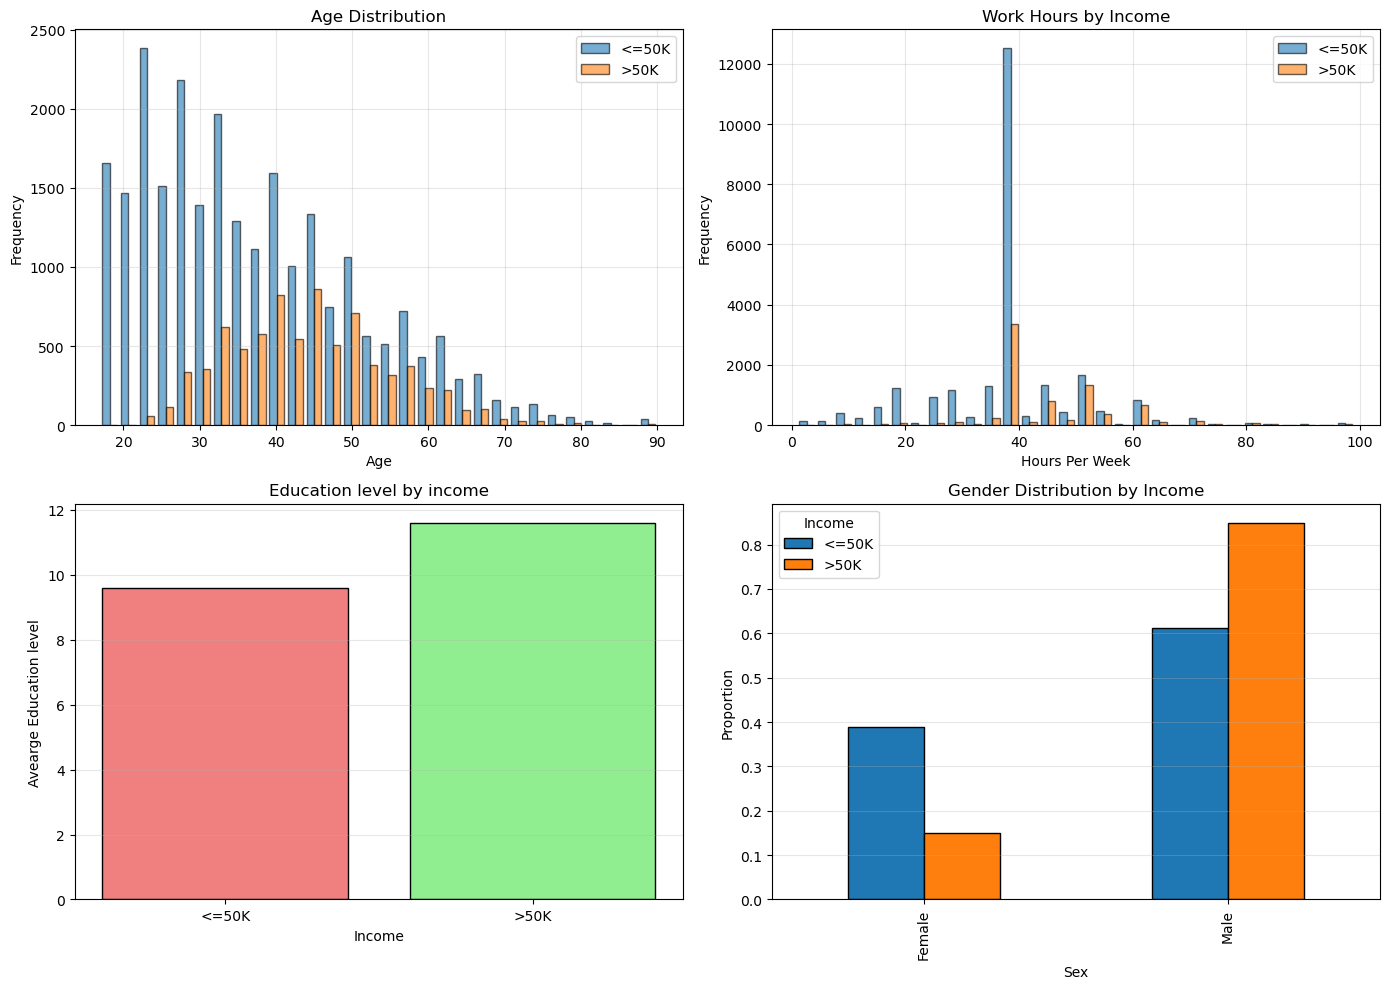


 OBSERVATIONS:
  • Higher income people tend to be older
  • They work more hours
  • They have more education
  • Gender imbalance exists in high-income group


In [6]:
#How features relate to income

print("Features vs Income")
print("=" * 60)

fig,axes = plt.subplots(2,2, figsize = (14,10))

low_income = df_clean[df_clean['income']=='<=50K']['age']
high_income = df_clean[df_clean['income']=='>50K']['age']

axes[0,0].hist([low_income,high_income],
bins = 30,
label = ['<=50K','>50K'],
alpha = 0.6,
edgecolor = 'black')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Age Distribution')
axes[0,0].legend()
axes[0,0].grid(True,alpha = 0.3)


low_hours = df_clean[df_clean['income'] == '<=50K']['hours_per_week']
high_hours = df_clean[df_clean['income']== '>50K']['hours_per_week']

axes[0,1].hist([low_hours,high_hours],
bins= 30,
label = ['<=50K','>50K'],
alpha= 0.6,
edgecolor = 'black')
axes[0,1].set_xlabel('Hours Per Week')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Work Hours by Income')
axes[0,1].legend()
axes[0,1].grid(True,alpha = 0.3)

edu_by_income = df_clean.groupby('income')['education_num'].mean()
axes[1,0].bar(edu_by_income.index, edu_by_income.values,
color=['lightcoral','lightgreen'],
edgecolor = 'black')
axes[1,0].set_xlabel('Income')
axes[1,0].set_ylabel('Avearge Education level')
axes[1,0].set_title('Education level by income')
axes[1,0].grid(True , alpha = 0.3,axis ='y')

sex_by_income = pd.crosstab(df_clean['sex'], df_clean['income'], normalize='columns')
sex_by_income.plot(kind='bar', ax=axes[1, 1], edgecolor='black')
axes[1, 1].set_title('Gender Distribution by Income')
axes[1, 1].set_xlabel('Sex')
axes[1, 1].set_ylabel('Proportion')
axes[1, 1].legend(title='Income')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n OBSERVATIONS:")
print("  • Higher income people tend to be older")
print("  • They work more hours")
print("  • They have more education")
print("  • Gender imbalance exists in high-income group")



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(" LOGISTIC REGRESSION FROM SCRATCH")
print("="*60)

df = pd.read_csv('adult.data.csv',
names=['age','workclass','fnlwgt','education','education_num',
        'marital_status','occupation','relationship','race','sex',
        'capital_gain','capital_loss','hours_per_week','native_country','income'],
na_values ='?',
skipinitialspace = True)

df.dropna()
print(f"Data loaded: {df.shape[0]:,} samples,{df.shape[1]} features")

 LOGISTIC REGRESSION FROM SCRATCH
Data loaded: 32,561 samples,15 features


In [8]:
print(" PREPARING FEATURES AND TARGET")
print("="*60)

y =(df['income'] == '>50K').astype(int).values
print(f"Target distribution:")
print(f"  0 (≤50K): {sum(y==0)} ({sum(y==0)/len(y)*100:.1f}%)")
print(f"  1 (>50K): {sum(y==1)} ({sum(y==1)/len(y)*100:.1f}%)")

numerical_features = ['age', 'education_num','capital_gain','capital_loss','hours_per_week']
x_numerical = df[numerical_features].values

print(f" Using {len(numerical_features)} numerical features: ")
for feat in numerical_features:
    print(f"{feat}")


 PREPARING FEATURES AND TARGET
Target distribution:
  0 (≤50K): 24720 (75.9%)
  1 (>50K): 7841 (24.1%)
 Using 5 numerical features: 
age
education_num
capital_gain
capital_loss
hours_per_week


THE SIGMOID FUNCTION


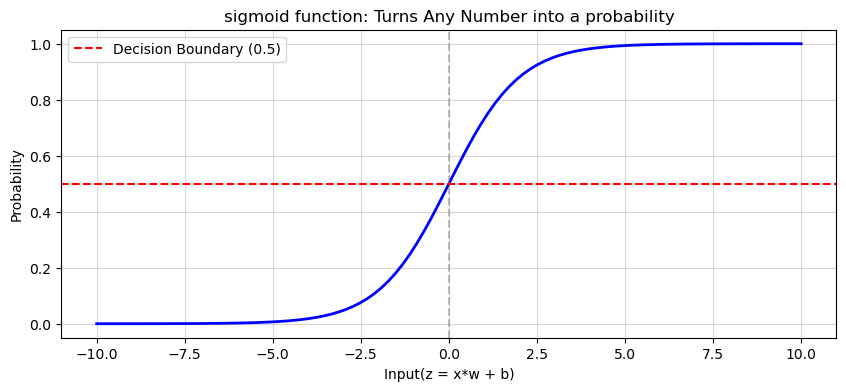

In [9]:
#using sigmoid function
print("THE SIGMOID FUNCTION")
print("=" * 60)

def sigmoid(z):#squashes any number into probability between 0 and 1
    return 1/ (1 + np.exp(-z))

z = np.linspace(-10,10,100)# This creates 100 evenly spaced numbes between -10 and 10
probabilities = sigmoid(z)


plt.figure(figsize=(10,4))
plt.plot(z, probabilities,'b-',linewidth=2)
plt.axhline(0.5,color='red',linestyle='--',label='Decision Boundary (0.5)')
plt.axvline(0,color='gray',linestyle='--',alpha = 0.5)
plt.xlabel('Input(z = x*w + b)')
plt.ylabel('Probability')
plt.title('sigmoid function: Turns Any Number into a probability')
plt.grid(True,alpha = 0.5)
plt.legend()
plt.show()




In [10]:
print(" STEP 4: BUILDING LOGISTIC REGRESSION FROM SCRATCH")
print("="*60)

class LogisticRegression:

    def __init__(self, learning_rate=0.001, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self,z):
        return 1 / (1 + np.exp(-z))


    def fit(self, x, y):
        n_samples,n_features = x.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.n_iterations):
            linear_output = np.dot(x, self.weights) + self.bias # y = w*x + b
            y_pred  = self.sigmoid(linear_output)

            epsilon = 1e-15
            pred = np.clip(y_pred, epsilon, 1-epsilon)
            loss = -np.mean(y * np.log(pred) + (1-y) * np.log(1-pred))
            self.loss_history.append(loss)


            dw = (1/n_samples) * np.dot(x.T, (y_pred -y))
            db = (1/n_samples) * np.sum(y_pred - y)
 
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db 

        if i % 200 == 0:
            print(f" Iteration {i}: loss: {loss:.4f}")
        print(f"\n Training complete! Final loss: {loss:.4f}")

    def predict_proba(self, x):
        linear_output = np.dot(x, self.weights) + self.bias
        return self.sigmoid(linear_output)

    def predict(self, x, threshold=0.5):
        probabilities = self.predict_proba(x)
        return (probabilities >=threshold).astype(int)
        
    def accuracy(self, x, y):
        y_pred = self.predict(x)
        print("Prediction shape:", y_pred.shape)
        print("Actual shape:", y.shape)
        return np.mean(y_pred == y)



 STEP 4: BUILDING LOGISTIC REGRESSION FROM SCRATCH


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("  TRAIN-TEST SPLIT & SCALING")
print("="*60)

x_train,x_test,y_train,y_test = train_test_split(
    x_numerical,y,test_size = 0.2,random_state = 42,stratify = y
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("\n Features scaled (mean=0, std=1)")
print("   First patient (before scaling):", x_train[0].round(1))
print("   First patient (after scaling): ", x_train_scaled[0].round(2))

  TRAIN-TEST SPLIT & SCALING

 Features scaled (mean=0, std=1)
   First patient (before scaling): [32 13  0  0 45]
   First patient (after scaling):  [-0.48  1.13 -0.15 -0.22  0.36]


In [12]:
print(" STEP 6: TRAINING MODEL")
print("="*60)

model = LogisticRegression(learning_rate=0.001 , n_iterations=1000)
model.fit(x_train_scaled,y_train)



y_train_pred = model.predict(x_train_scaled)
y_test_pred = model.predict(x_test_scaled)

train_acc= model.accuracy(x_train_scaled,y_train)
test_acc= model.accuracy(x_test_scaled,y_test)


print(" RESULTS")
print("=" * 60)
print(f"Training Accuracy:{train_acc:.4f} ({train_acc* 100:.1f}%)")
print(f"Testing Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

baseline = max(y.mean(),1-y.mean())
print(f"\n Baseline Accuracy (always predict majority class): {baseline:.4f} ({baseline*100:.1f}%)")
print(f" Your model improves over baseline by: {(test_acc - baseline)*100:.1f} percentage points")

 STEP 6: TRAINING MODEL

 Training complete! Final loss: 0.6010
Prediction shape: (26048,)
Actual shape: (26048,)
Prediction shape: (6513,)
Actual shape: (6513,)
 RESULTS
Training Accuracy:0.8009 (80.1%)
Testing Accuracy: 0.8039 (80.4%)

 Baseline Accuracy (always predict majority class): 0.7592 (75.9%)
 Your model improves over baseline by: 4.5 percentage points


In [13]:
# CELL 7: Confusion Matrix
from sklearn.metrics import confusion_matrix

print(" STEP 7: CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print("                 PREDICTED")
print("                 Low    High")
print(f"ACTUAL   Low     {tn:5d}  {fp:5d}")
print(f"         High    {fn:5d}  {tp:5d}")
print()

print(f" Interpretation:")
print(f"  • True Negatives (TN): {tn} - Correctly predicted LOW income")
print(f"  • False Positives (FP): {fp} - Predicted HIGH but actually LOW")
print(f"  • False Negatives (FN): {fn} - Predicted LOW but actually HIGH ⚠️")
print(f"  • True Positives (TP): {tp} - Correctly predicted HIGH income")

# Calculate metrics
accuracy = (tn + tp) / (tn + fp + fn + tp)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f} (When model says HIGH, how often is it right?)")
print(f"  Recall:    {recall:.4f} (What % of actual HIGH did we catch?)")
print(f"  F1-Score:  {f1:.4f} (Balance between precision and recall)")

 STEP 7: CONFUSION MATRIX
                 PREDICTED
                 Low    High
ACTUAL   Low      4688    257
         High     1020    548

 Interpretation:
  • True Negatives (TN): 4688 - Correctly predicted LOW income
  • False Positives (FP): 257 - Predicted HIGH but actually LOW
  • False Negatives (FN): 1020 - Predicted LOW but actually HIGH ⚠️
  • True Positives (TP): 548 - Correctly predicted HIGH income

 Metrics:
  Accuracy:  0.8039
  Precision: 0.6807 (When model says HIGH, how often is it right?)
  Recall:    0.3495 (What % of actual HIGH did we catch?)
  F1-Score:  0.4619 (Balance between precision and recall)


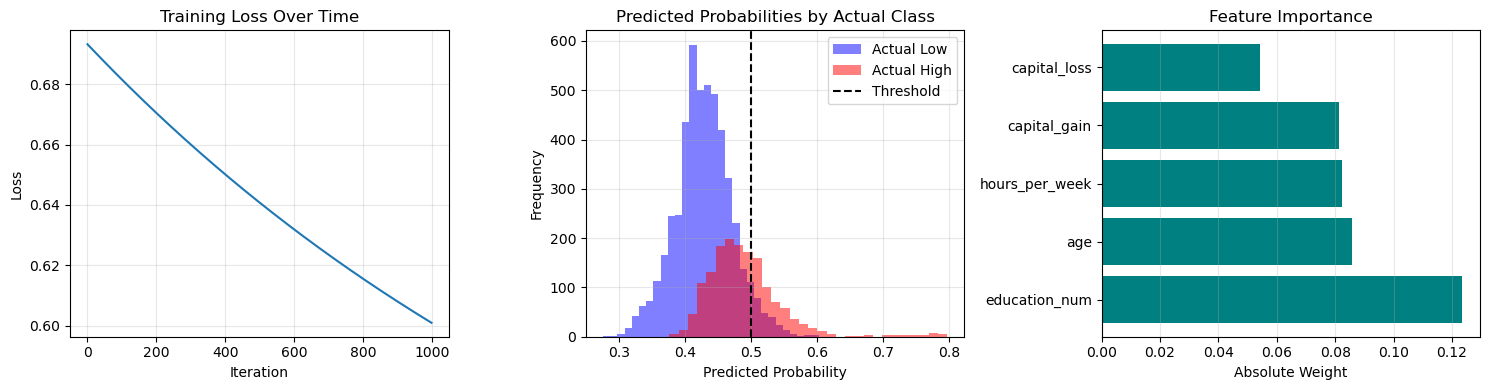


 Most important features:
  • education_num: weight = 0.1234
  • age: weight = 0.0859
  • hours_per_week: weight = 0.0824


In [15]:
# CELL 8: Plot learning curve and predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss over time
axes[0].plot(model.loss_history)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Over Time')
axes[0].grid(True, alpha=0.3)

# Probability distribution for test set
y_test_proba = model.predict_proba(x_test_scaled)
axes[1].hist(y_test_proba[y_test==0], bins=30, alpha=0.5, label='Actual Low', color='blue')
axes[1].hist(y_test_proba[y_test==1], bins=30, alpha=0.5, label='Actual High', color='red')
axes[1].axvline(0.5, color='black', linestyle='--', label='Threshold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Predicted Probabilities by Actual Class')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Feature importance (absolute weights)
features = numerical_features
importance = np.abs(model.weights)
sorted_idx = np.argsort(importance)[::-1]
axes[2].barh([features[i] for i in sorted_idx], importance[sorted_idx], color='teal')
axes[2].set_xlabel('Absolute Weight')
axes[2].set_title('Feature Importance')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n Most important features:")
for i in sorted_idx[:3]:
    print(f"  • {features[i]}: weight = {model.weights[i]:.4f}")

In [18]:
# CELL 9: Validate with sklearn
from sklearn.linear_model import LogisticRegression as SklearnLogistic

print(" STEP 9: VALIDATING WITH SKLEARN")
print("="*60)

sk_model = SklearnLogistic(max_iter=2000)
sk_model.fit(x_train_scaled, y_train)
sk_pred = sk_model.predict(x_test_scaled)
sk_acc = np.mean(sk_pred == y_test)

print(f"Your Model Accuracy:  {test_acc:.4f}")
print(f"sklearn Accuracy:     {sk_acc:.4f}")
print(f"Difference:           {abs(test_acc - sk_acc):.4f}")

if abs(test_acc - sk_acc) < 0.02:
    print("\n EXCELLENT! Your model matches sklearn!")
else:
    print("\n Small difference - let's debug if needed.")

 STEP 9: VALIDATING WITH SKLEARN
Your Model Accuracy:  0.8039
sklearn Accuracy:     0.8174
Difference:           0.0135

 EXCELLENT! Your model matches sklearn!


 STEP 10: THRESHOLD TUNING


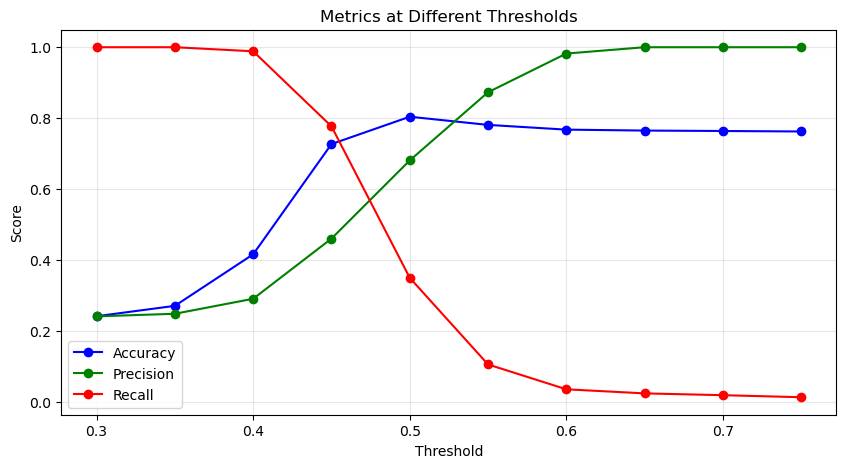

Best accuracy: 0.8039 at threshold = 0.50


In [20]:
# CELL 10: Adjust threshold
print(" STEP 10: THRESHOLD TUNING")
print("="*60)

thresholds = np.arange(0.3, 0.8, 0.05)
accuracies = []
precisions = []
recalls = []

for threshold in thresholds:
    y_pred = model.predict(x_test_scaled, threshold=threshold)
    acc = np.mean(y_pred == y_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(thresholds, accuracies, 'b-o', label='Accuracy')
plt.plot(thresholds, precisions, 'g-o', label='Precision')
plt.plot(thresholds, recalls, 'r-o', label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics at Different Thresholds')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_idx = np.argmax(accuracies)
print(f"Best accuracy: {accuracies[best_idx]:.4f} at threshold = {thresholds[best_idx]:.2f}")

In [ ]:
#  LOGISTIC REGRESSION - KEY TAKEAWAYS

## What I Learned Today
1. **Sigmoid Function** - Turns any number into a probability
2. **Cross-Entropy Loss** - Measures how wrong probabilities are
3. **Decision Threshold** - Default 0.5, but can be tuned
4. **Confusion Matrix** - Shows types of errors (FP, FN, TP, TN)
5. **Precision vs Recall** - Trade-off between being correct vs catching all positives

## My Results
- **Test Accuracy:** ___%
- **Baseline:** 76%
- **Improvement:** _4.5 percentage points
- **Best Threshold:** ___

## Important Concepts for Quant Finance
- **False Negatives** (missing high-risk cases) are often more costly than False Positives
- **Probability outputs** are more valuable than just classifications
- **Threshold tuning** depends on business context (cost of mistakes)

## Questions for Tomorrow
1. How do I handle categorical features?
2. What if classes are more imbalanced?
3. How does this compare to Linear Regression?